## Preprocessing

### 0. Index
1. Train/Test split
3. Save processed data
4. Preprocessing summary


During the exploratory data analysis phase, a significant number of duplicate rows were identified and removed, reducing the dataset from 1025 to 302 observations.

The dataset does not require imputation because no missing values or invalid zero values were detected. The target variable is balanced, so a stratified train-test split will be used to preserve class proportions. Outliers are retained at this stage because they may represent clinically meaningful patient variation rather than data errors.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# This adds the parent directory (project root) to the Python path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if root_path not in sys.path:
    sys.path.append(root_path)

In [3]:
from src.utils.config import CFG, PROJECT_ROOT

In [4]:
#Load data
df = pd.read_csv(PROJECT_ROOT / CFG["paths"]["raw_data"])

In [5]:
df_clean = df.drop_duplicates()

In [6]:
df_clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1. Train/Test split
goal: 
302 patients:
    - train: 181 (60%) - used for the model to learn patterns from the data.
    - val: 61(20%) - used fro hyperparameter tuning and model selection.
    - test: 60(20%) - used for final model evaluation, one time use

In [7]:
from src.data.split_data import split_data 

X_train, X_val, X_test, Y_train, Y_val, Y_test = split_data(df_clean)

The class proportions remain consistent across the training and testing sets, confirming that stratification preserved the target distribution.

figure saves in /Users/miluskapajuelo/Documents/Heart-Disease-Prediction-using-Machine-Learning-End-to-End-ML-Pipeline-/figures/split_class_balance.png


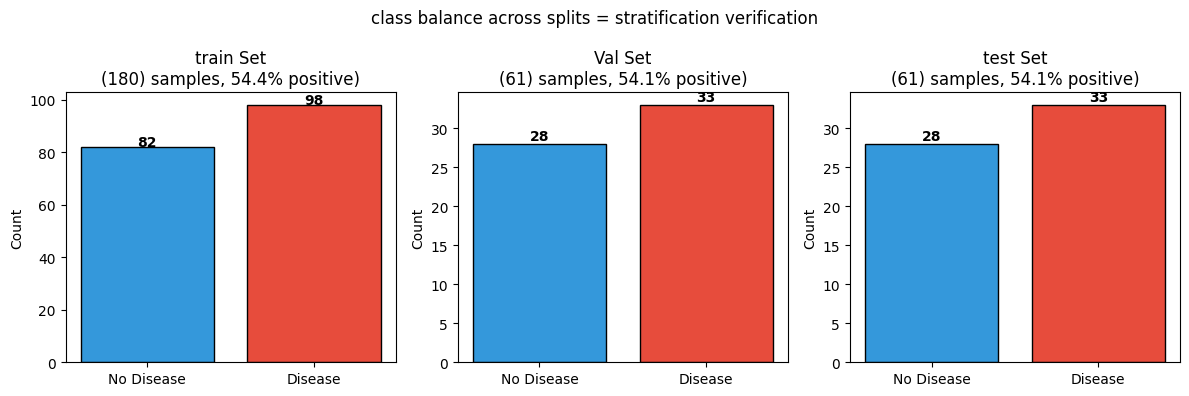

In [8]:
from src.utils.helpers import save_figure
# verify the balance of classes preservation stratification

splits_info ={
    "train":Y_train,
    "Val":Y_val,
    "test": Y_test
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, y) in zip(axes, splits_info.items()):
    counts = y.value_counts().sort_index()
    ax.bar(
        ['No Disease', 'Disease'],
        counts.values,
        color=["#3498db", '#e74c3c'],
        edgecolor= 'black'
    )
    ax.set_title(f'{name} Set\n({len(y)}) samples, {y.mean():.1%} positive)')
    ax.set_ylabel('Count')

    for i, v in enumerate(counts.values):
        ax.text(i, v+0.5, str(v), ha="center", fontweight="bold")

plt.suptitle(
    'class balance across splits = stratification verification',
    fontsize=12
)
plt.tight_layout()
save_figure(
    fig,
    PROJECT_ROOT / CFG['paths']['figures_dir'] / 'split_class_balance.png'
)


### 2. Replace 0 to NaN

goal: I have identified attributes that should not contain zero, and if they contain zeros, they will be replace by NaN before the imputer process

In [9]:
zero_cols = CFG["preprocessing"]["zero_as_nan_col"]
zero_cols

['chol', 'trestbps', 'thalach']

In [13]:
from src.data.preprocess import replace_zero_with_nan, fit_imputer, add_engineered_features


In [11]:
# replace zero in all 3 splits
x_train_proc = replace_zero_with_nan(X_train, zero_cols)
x_val_proc = replace_zero_with_nan(X_val, zero_cols)
x_test_proc = replace_zero_with_nan(X_test, zero_cols)

### 3. Imputation - fit on train only

goal: fill missing values using the median learned from the training set only

These same medians are applied to `X_val` and `X_test` without refitting. This prevents data leakage — test information never influences the imputation values used during training.

The fitted imputer is saved as `models/preprocessor.pkl` for production use. When a new patient arrives, their data goes through the exact same
transformation with the exact same medians.

In [12]:
X_train_imp, X_test_imp, X_val_imp, imputer = fit_imputer(x_train_proc, x_val_proc, x_test_proc)

 medians learned from training set 

 age:  55.00
 sex:  1.00
 cp:  1.00
 trestbps:  130.00
 chol:  241.50
 fbs:  0.00
 restecg:  0.50
 thalach:  154.50
 exang:  0.00
 oldpeak:  0.60
 slope:  1.00
 ca:  0.00
 thal:  2.00


### 4. Feature engineering

goal: encode clinical domain knowledge into 4 composite features that capture relationship between raw variables. I worked with dr. Morgan Carson-Marino(PharmD, MS)

Four new features are created from the imputed data:

| Feature | Formula | Clinical Meaning |
|---|---|---|
| `cardiac_capacity` | `thalach / age` | Max heart rate efficiency relative to age |
| `isquemia_score` | `(oldpeak / oldpeak_max) + exang + (ca / 3)` | Composite ischemia risk |
| `est_stroke_volume` | `(trestbps / thalach) × (age / 50)` | Proxy for cardiac work efficiency |
| `troponin_index` | `(oldpeak × 1.5) + (exang × 2) + (ca × 1.2)` | Weighted ischemia marker |


After engineering, 8 features are selected based on clinical
relevance and correlation with the target.

In [15]:
X_train_fe, X_val_fe, X_test_fe, oldpeak_max = add_engineered_features(
    X_train_imp, X_test_imp, X_val_imp
)

In [19]:
X_train_fe.shape


(180, 8)

In [ ]:
# version without scale
X_train_raw, X_val_raw = X_train_fe, X_val_fe

In [ ]:
#version with standardScaler

